# Assignment 1 — Multimodal Classification with UPMC Food-101, CLIP, and Tip-Adapter

This Colab notebook implements the **multimodal requirement in Section 4.3** of the assignment using:

- **Dataset**: UPMC Food-101 (image + paired title text)
- **Backbone**: pretrained **OpenAI CLIP ViT-B/32**
- **Zero-shot setting**: no labeled support examples from the target dataset
- **Few-shot setting**: **Tip-Adapter** with a small support set built from labeled image-title pairs

## What this notebook does

1. Downloads the **UPMC Food-101** Kaggle dataset.
2. Loads the paired **image + title** data from `train_titles.csv` and `test_titles.csv`.
3. Selects a **10-class subset** (we can change this).
4. Encodes each sample with CLIP:
   - image embedding
   - text/title embedding
   - **fused multimodal embedding**
5. Evaluates:
   - **Zero-shot multimodal CLIP**
   - **Few-shot multimodal Tip-Adapter** for several shot counts
6. Reports:
   - accuracy
   - macro-F1
   - confusion matrix
   - shot-vs-performance table and plot

## Important note about Tip-Adapter in this notebook

The original Tip-Adapter paper is for **vision classification**.  
To make it fit the **multimodal assignment**, this notebook applies the same cache-based idea to a **fused CLIP embedding** built from:

$$
z_{fused} = \text{normalize}(\lambda_{img} z_{img} + \lambda_{txt} z_{txt})
$$

That means the **cache keys** are created from **paired image-title examples**, not image-only examples.

This makes the method still faithful to the Tip-Adapter idea, while also satisfying the assignment's **genuine image-text pair** requirement.

## Runtime setup

In Colab:
1. Set **Runtime → Change runtime type → GPU**
2. Run the install cell
3. When prompted, paste your **Kaggle API token** (starts with `KGAT`), or set `KAGGLE_API_TOKEN` in the environment

In [ ]:
# Install dependencies
!pip -q install ftfy regex tqdm kaggle scikit-learn seaborn pandas pillow matplotlib git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done


In [ ]:
import os
import random
import json
import math
from pathlib import Path
from collections import defaultdict
import subprocess
import getpass

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display, HTML

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import clip

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Experiment configuration

You can change:
- `NUM_CLASSES`
- `SHOT_LIST` to make the notebook runs the few-shot experiment (e.g. with [1, ,4, 8, 16] = 1, 4, 8, and 16 examples per class.)
- `SELECTED_CLASSES` if you want a fixed subset
- the fusion weights `IMAGE_WEIGHT` and `TEXT_WEIGHT`

In [ ]:
# =========================
# Main experiment settings
# =========================

DATA_ROOT = Path("/content/data")
DATASET_SLUG = "gianmarco96/upmcfood101"

NUM_CLASSES = 10
SELECTED_CLASSES = None   # Example: ["pizza", "pancakes", "tacos", ...] or None for automatic selection
SHOT_LIST = [1, 4, 8, 16]

VAL_RATIO = 0.15
MIN_SAMPLES_PER_CLASS = 40   # safety threshold after filtering
BATCH_SIZE = 64
NUM_WORKERS = 2

# Fusion weights for multimodal CLIP representation
IMAGE_WEIGHT = 0.6
TEXT_WEIGHT = 0.4

# CLIP prompt templates for class prototypes
PROMPT_TEMPLATES = [
    "a photo of {}",
    "a food photo of {}",
    "a dish of {}",
    "a recipe for {}",
    "a recipe title about {}",
]

# Hyperparameter search for Tip-Adapter
BETA_GRID = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
ALPHA_GRID = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]

# Optional quick-run cap for debugging. Set to None for full run.
MAX_TRAIN_PER_CLASS = None
MAX_VAL_PER_CLASS = None
MAX_TEST_PER_CLASS = None

## Download the Kaggle dataset

This notebook expects the UPMC Food-101 Kaggle package used in prior public notebooks for this dataset, where the paired title files are named:

- `train_titles.csv`
- `test_titles.csv`

If you already downloaded the dataset into `/content/data`, this cell will skip the download.

In [ ]:
def ensure_kaggle_credentials():
    kaggle_dir = Path("/root/.kaggle")
    access_token_file = kaggle_dir / "access_token"

    if access_token_file.exists():
        os.chmod(access_token_file, 0o600)
        return

    api_token = os.getenv("KAGGLE_API_TOKEN")
    if api_token:
        kaggle_dir.mkdir(parents=True, exist_ok=True)
        access_token_file.write_text(api_token.strip())
        os.chmod(access_token_file, 0o600)
        return

    token = getpass.getpass("Paste your Kaggle API token (starts with KGAT): ").strip()
    if not token:
        raise RuntimeError("No Kaggle API token provided.")

    kaggle_dir.mkdir(parents=True, exist_ok=True)
    access_token_file.write_text(token)
    os.chmod(access_token_file, 0o600)


def maybe_download_dataset():
    existing_train = list(DATA_ROOT.rglob("train_titles.csv"))
    existing_test = list(DATA_ROOT.rglob("test_titles.csv"))

    if existing_train and existing_test:
        display(HTML("<b>Dataset already present.</b> Skipping download."))
        return

    ensure_kaggle_credentials()
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    display(HTML(f"<b>Downloading dataset:</b> <code>{DATASET_SLUG}</code>"))

    cmd = f'kaggle datasets download -d "{DATASET_SLUG}" -p "{DATA_ROOT}" --unzip'
    exit_code = os.system(cmd)

    if exit_code != 0:
        raise RuntimeError("Kaggle download failed.")

    existing_train = list(DATA_ROOT.rglob("train_titles.csv"))
    existing_test = list(DATA_ROOT.rglob("test_titles.csv"))
    if not (existing_train and existing_test):
        raise FileNotFoundError(
            "Downloaded dataset, but could not find train_titles.csv / test_titles.csv."
        )

    display(HTML("<b>Download complete.</b>"))

maybe_download_dataset()

Paste your Kaggle API token (starts with KGAT): ··········


## Locate dataset files and inspect the structure



In [ ]:
def find_first(root: Path, pattern: str):
    matches = list(root.rglob(pattern))
    if not matches:
        raise FileNotFoundError(f"Could not find {pattern} under {root}")
    return matches[0]

train_csv = find_first(DATA_ROOT, "train_titles.csv")
test_csv = find_first(DATA_ROOT, "test_titles.csv")
dataset_root = train_csv.parent.parent

print("Dataset root:", dataset_root)
print("Train CSV:", train_csv)
print("Test CSV:", test_csv)

Dataset root: /content/data
Train CSV: /content/data/texts/train_titles.csv
Test CSV: /content/data/texts/test_titles.csv


In [ ]:
# Read the title CSV files.
# Public notebooks for this dataset use the format:
# image_path,text,food
COLUMN_NAMES = ["image_path", "text", "food"]

train_df = pd.read_csv(train_csv, names=COLUMN_NAMES, header=None)
test_df = pd.read_csv(test_csv, names=COLUMN_NAMES, header=None)

train_df["split"] = "train"
test_df["split"] = "test"

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())

Train shape: (67972, 4)
Test shape: (22716, 4)


,image_path,text,food,split
0,apple_pie_851.jpg,Crock-Pot Ladies Crock-Pot Apple Pie Moonshine,apple_pie,train
1,apple_pie_140.jpg,Mom's Maple-Apple Pie Recipe | Taste of Home,apple_pie,train
2,apple_pie_858.jpg,Cookin&#8217; Canuck &#8211; Baked Apple Pie E...,apple_pie,train
3,apple_pie_449.jpg,Dutch Apple Pie Recipe | Just A Pinch Recipes,apple_pie,train
4,apple_pie_695.jpg,Our Share of the Harvest &raquo; Grandma&#8217...,apple_pie,train


## Resolve image paths

The CSV contains image file names such as `tacos_232.jpg`.  
This helper searches the dataset folder recursively and maps each file name to its actual path.

In [ ]:
def build_image_lookup(root: Path):
    filename_to_path = {}
    rel_to_path = {}

    image_files = []
    for pattern in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
        image_files.extend(root.rglob(pattern))

    for p in image_files:
        filename_to_path.setdefault(p.name, str(p))
        try:
            rel_to_path[str(p.relative_to(root)).replace("\\", "/")] = str(p)
        except Exception:
            pass

    return filename_to_path, rel_to_path


def resolve_image_path(x, filename_to_path, rel_to_path):
    x = str(x).strip().replace("\\", "/")
    if x in rel_to_path:
        return rel_to_path[x]
    name = Path(x).name
    return filename_to_path.get(name, None)


filename_to_path, rel_to_path = build_image_lookup(dataset_root)

for df in [train_df, test_df]:
    df["resolved_image_path"] = df["image_path"].apply(
        lambda x: resolve_image_path(x, filename_to_path, rel_to_path)
    )

missing_train = train_df["resolved_image_path"].isna().sum()
missing_test = test_df["resolved_image_path"].isna().sum()

print("Missing train images:", missing_train)
print("Missing test images:", missing_test)

train_df = train_df.dropna(subset=["resolved_image_path"]).reset_index(drop=True)
test_df = test_df.dropna(subset=["resolved_image_path"]).reset_index(drop=True)

print("Train after image resolution:", train_df.shape)
print("Test after image resolution:", test_df.shape)

Missing train images: 0
Missing test images: 0
Train after image resolution: (67972, 5)
Test after image resolution: (22716, 5)


## Clean text and choose the class subset

In [ ]:
def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = " ".join(text.split())
    return text.strip()

train_df["text"] = train_df["text"].map(clean_text)
test_df["text"] = test_df["text"].map(clean_text)

# Remove empty text rows to keep the multimodal setting genuine
train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["text"].str.len() > 0].reset_index(drop=True)

train_counts = train_df["food"].value_counts()
test_counts = test_df["food"].value_counts()

eligible_classes = [
    cls for cls in train_counts.index
    if train_counts[cls] >= MIN_SAMPLES_PER_CLASS and test_counts.get(cls, 0) >= MIN_SAMPLES_PER_CLASS
]

if SELECTED_CLASSES is None:
    selected_classes = eligible_classes[:NUM_CLASSES]
else:
    missing = [c for c in SELECTED_CLASSES if c not in eligible_classes]
    if missing:
        raise ValueError(f"Some selected classes are not eligible: {missing}")
    selected_classes = SELECTED_CLASSES[:NUM_CLASSES]

print("Selected classes:", selected_classes)

train_df = train_df[train_df["food"].isin(selected_classes)].copy()
test_df = test_df[test_df["food"].isin(selected_classes)].copy()

label_to_id = {label: idx for idx, label in enumerate(selected_classes)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

train_df["label_id"] = train_df["food"].map(label_to_id)
test_df["label_id"] = test_df["food"].map(label_to_id)

print("Train subset size:", len(train_df))
display(train_df["food"].value_counts())
print("Test subset size:", len(test_df))
display(test_df["food"].value_counts())

Selected classes: ['macaroni_and_cheese', 'french_toast', 'sushi', 'risotto', 'ravioli', 'waffles', 'pizza', 'hot_dog', 'apple_pie', 'hummus']
Train subset size: 7055


,count
food,
macaroni_and_cheese,713
french_toast,711
sushi,710
risotto,708
ravioli,705
waffles,703
pizza,702
apple_pie,701
hot_dog,701


Test subset size: 2357


,count
food,
french_toast,238
macaroni_and_cheese,238
sushi,237
ravioli,236
risotto,236
pizza,235
waffles,235
apple_pie,234
hot_dog,234


In [ ]:
# Optional per-class caps for quicker experiments
def cap_per_class(df, max_per_class=None, seed=SEED):
    if max_per_class is None:
        return df.reset_index(drop=True)
    parts = []
    for _, group in df.groupby("label_id", sort=True):
        parts.append(group.sample(n=min(max_per_class, len(group)), random_state=seed))
    return pd.concat(parts).reset_index(drop=True)

train_df = cap_per_class(train_df, MAX_TRAIN_PER_CLASS)
test_df = cap_per_class(test_df, MAX_TEST_PER_CLASS)

print("Train subset size:", len(train_df))
print("Test subset size:", len(test_df))

Train subset size: 7055
Test subset size: 2357


## Dataset validity for the assignment

We use a 10-class subset of UPMC Food-101. This still satisfies the assignment constraints because:
- it is a genuine multimodal dataset with paired **image + title text**
- it has **more than 5 classes**
- it contains enough samples for meaningful zero-shot and few-shot comparison

## EDA: dataset overview and distributions

This section provides a compact exploratory data analysis (EDA) of the **selected** multimodal subset used above. It checks:

- split sizes and class counts
- class balance across train / validation-test source split
- title-length distribution
- image resolution / aspect-ratio distribution
- a few example image-title pairs

These plots help justify the dataset choice and highlight potential issues before zero-shot and few-shot evaluation.


In [ ]:
# Basic dataset summary for the selected multimodal subset
eda_summary = pd.DataFrame({
    "split": ["train_subset", "test_subset"],
    "num_samples": [len(train_df), len(test_df)],
    "num_classes": [train_df["food"].nunique(), test_df["food"].nunique()],
    "avg_title_len_words": [
        train_df["text"].str.split().map(len).mean(),
        test_df["text"].str.split().map(len).mean(),
    ],
    "median_title_len_words": [
        train_df["text"].str.split().map(len).median(),
        test_df["text"].str.split().map(len).median(),
    ],
    "min_samples_per_class": [
        train_df["food"].value_counts().min(),
        test_df["food"].value_counts().min(),
    ],
    "max_samples_per_class": [
        train_df["food"].value_counts().max(),
        test_df["food"].value_counts().max(),
    ],
})

print("Selected classes:", selected_classes)
display(eda_summary)

missing_summary = pd.DataFrame({
    "split": ["train_subset", "test_subset"],
    "missing_text": [train_df["text"].isna().sum(), test_df["text"].isna().sum()],
    "empty_text": [(train_df["text"].str.len() == 0).sum(), (test_df["text"].str.len() == 0).sum()],
    "missing_resolved_image_path": [
        train_df["resolved_image_path"].isna().sum(),
        test_df["resolved_image_path"].isna().sum(),
    ],
})
display(missing_summary)


Selected classes: ['macaroni_and_cheese', 'french_toast', 'sushi', 'risotto', 'ravioli', 'waffles', 'pizza', 'hot_dog', 'apple_pie', 'hummus']


,split,num_samples,num_classes,avg_title_len_words,median_title_len_words,min_samples_per_class,max_samples_per_class
0,train_subset,7055,10,8.677817,8.0,701,713
1,test_subset,2357,10,8.697497,8.0,234,238


,split,missing_text,empty_text,missing_resolved_image_path
0,train_subset,0,0,0
1,test_subset,0,0,0


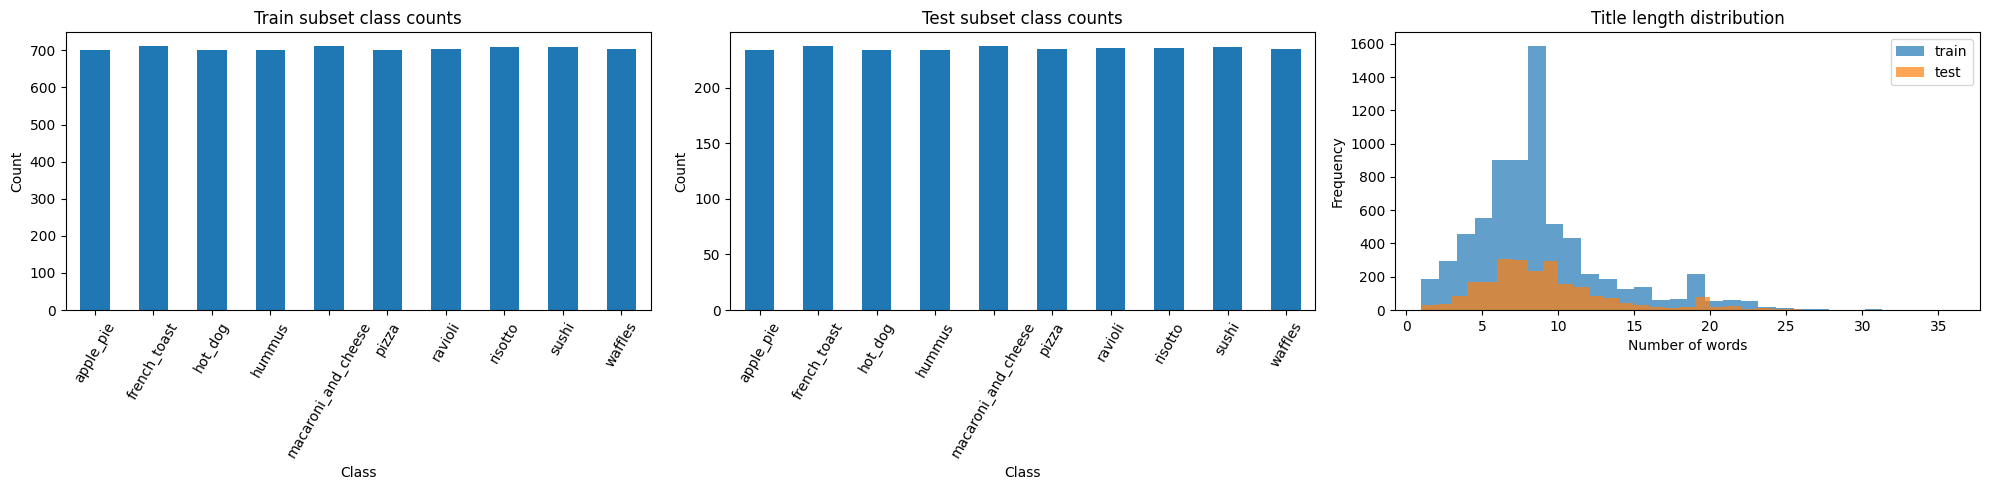

,split,mean_words,std_words,p10_words,p90_words
0,train_subset,8.677817,4.490084,4.0,14.0
1,test_subset,8.697497,4.485466,4.0,15.0


In [ ]:
# Class distribution and title-length distribution
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

train_counts_plot = train_df["food"].value_counts().sort_index()
test_counts_plot = test_df["food"].value_counts().sort_index()

train_counts_plot.plot(kind="bar", ax=axes[0], title="Train subset class counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=60)

test_counts_plot.plot(kind="bar", ax=axes[1], title="Test subset class counts")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=60)

train_title_lens = train_df["text"].str.split().map(len)
test_title_lens = test_df["text"].str.split().map(len)

axes[2].hist(train_title_lens, bins=30, alpha=0.7, label="train")
axes[2].hist(test_title_lens, bins=30, alpha=0.7, label="test")
axes[2].set_title("Title length distribution")
axes[2].set_xlabel("Number of words")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.show()

title_len_stats = pd.DataFrame({
    "split": ["train_subset", "test_subset"],
    "mean_words": [train_title_lens.mean(), test_title_lens.mean()],
    "std_words": [train_title_lens.std(), test_title_lens.std()],
    "p10_words": [train_title_lens.quantile(0.10), test_title_lens.quantile(0.10)],
    "p90_words": [train_title_lens.quantile(0.90), test_title_lens.quantile(0.90)],
})
display(title_len_stats)


Reading image metadata:   0%|          | 0/500 [00:00<?, ?it/s]

Reading image metadata:   0%|          | 0/500 [00:00<?, ?it/s]

,split,num_images_profiled,mean_width,mean_height,mean_aspect_ratio
0,train_subset_sample,500,548.852,452.416,1.239208
1,test_subset_sample,500,535.320,449.668,1.237307


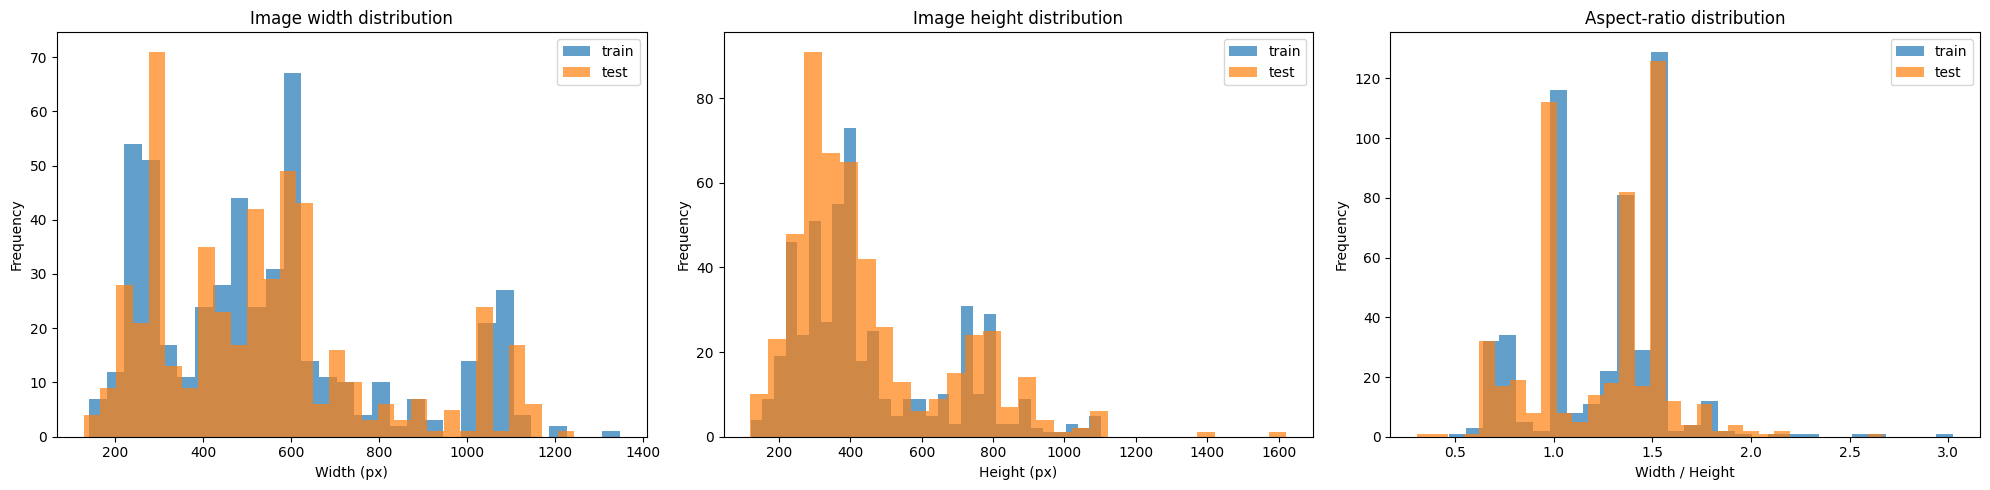

In [ ]:
# Inspect image resolution / aspect-ratio distribution on a sample for speed
def sample_image_stats(df, n=500, seed=SEED):
    sample_df = df.sample(min(n, len(df)), random_state=seed).copy()
    rows = []

    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Reading image metadata"):
        try:
            with Image.open(row["resolved_image_path"]) as img:
                w, h = img.size
            rows.append({
                "food": row["food"],
                "width": w,
                "height": h,
                "aspect_ratio": w / h if h else np.nan,
            })
        except Exception:
            continue

    return pd.DataFrame(rows)

train_img_stats = sample_image_stats(train_df, n=500, seed=SEED)
test_img_stats = sample_image_stats(test_df, n=500, seed=SEED + 1)

img_stats_summary = pd.DataFrame({
    "split": ["train_subset_sample", "test_subset_sample"],
    "num_images_profiled": [len(train_img_stats), len(test_img_stats)],
    "mean_width": [train_img_stats["width"].mean(), test_img_stats["width"].mean()],
    "mean_height": [train_img_stats["height"].mean(), test_img_stats["height"].mean()],
    "mean_aspect_ratio": [train_img_stats["aspect_ratio"].mean(), test_img_stats["aspect_ratio"].mean()],
})
display(img_stats_summary)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].hist(train_img_stats["width"], bins=30, alpha=0.7, label="train")
axes[0].hist(test_img_stats["width"], bins=30, alpha=0.7, label="test")
axes[0].set_title("Image width distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(train_img_stats["height"], bins=30, alpha=0.7, label="train")
axes[1].hist(test_img_stats["height"], bins=30, alpha=0.7, label="test")
axes[1].set_title("Image height distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].hist(train_img_stats["aspect_ratio"], bins=30, alpha=0.7, label="train")
axes[2].hist(test_img_stats["aspect_ratio"], bins=30, alpha=0.7, label="test")
axes[2].set_title("Aspect-ratio distribution")
axes[2].set_xlabel("Width / Height")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.show()


## EDA takeaway

1. The selected 10-class UPMC Food-101 subset is **clean and well balanced**, with
about 701–713 training samples and 234–238 test samples per class => This makes the classification setting **fair and suitable** for comparing zero-shot and few-shot performance.

2. The multimodal pairs are reliable: there are no missing titles, no empty text entries, and no unresolved image paths after preprocessing. The title texts are **short and consistent**, averaging about 8.7 words, so they provide useful semantic cues without being overly long.

3. The sampled image statistics show that train and test images have very **similar** size and aspect-ratio distributions, with average widths around 535–549 pixels and mean aspect ratio close to 1.24. Overall, the subset appears stable and appropriate for evaluating fused image-text classification with CLIP and Tip-Adapter.

## Build train-pool / validation split

- **Validation split** is used only to tune Tip-Adapter hyperparameters (`alpha`, `beta`)
- **Few-shot support sets** are sampled from the remaining train pool
- **Test split** stays untouched for the final report

In [ ]:
train_pool_df, val_df = train_test_split(
    train_df,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=train_df["label_id"],
)

train_pool_df = train_pool_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

val_df = cap_per_class(val_df, MAX_VAL_PER_CLASS)

print("Train pool:", train_pool_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(train_pool_df["food"].value_counts().sort_index())
display(val_df["food"].value_counts().sort_index())
display(test_df["food"].value_counts().sort_index())

Train pool: (5996, 6)
Validation: (1059, 6)
Test: (2357, 6)


,count
food,
apple_pie,596
french_toast,604
hot_dog,596
hummus,596
macaroni_and_cheese,606
pizza,597
ravioli,599
risotto,602
sushi,603


,count
food,
apple_pie,105
french_toast,107
hot_dog,105
hummus,105
macaroni_and_cheese,107
pizza,105
ravioli,106
risotto,106
sushi,107


,count
food,
apple_pie,234
french_toast,238
hot_dog,234
hummus,234
macaroni_and_cheese,238
pizza,235
ravioli,236
risotto,236
sushi,237


## Sample some image-title pairs

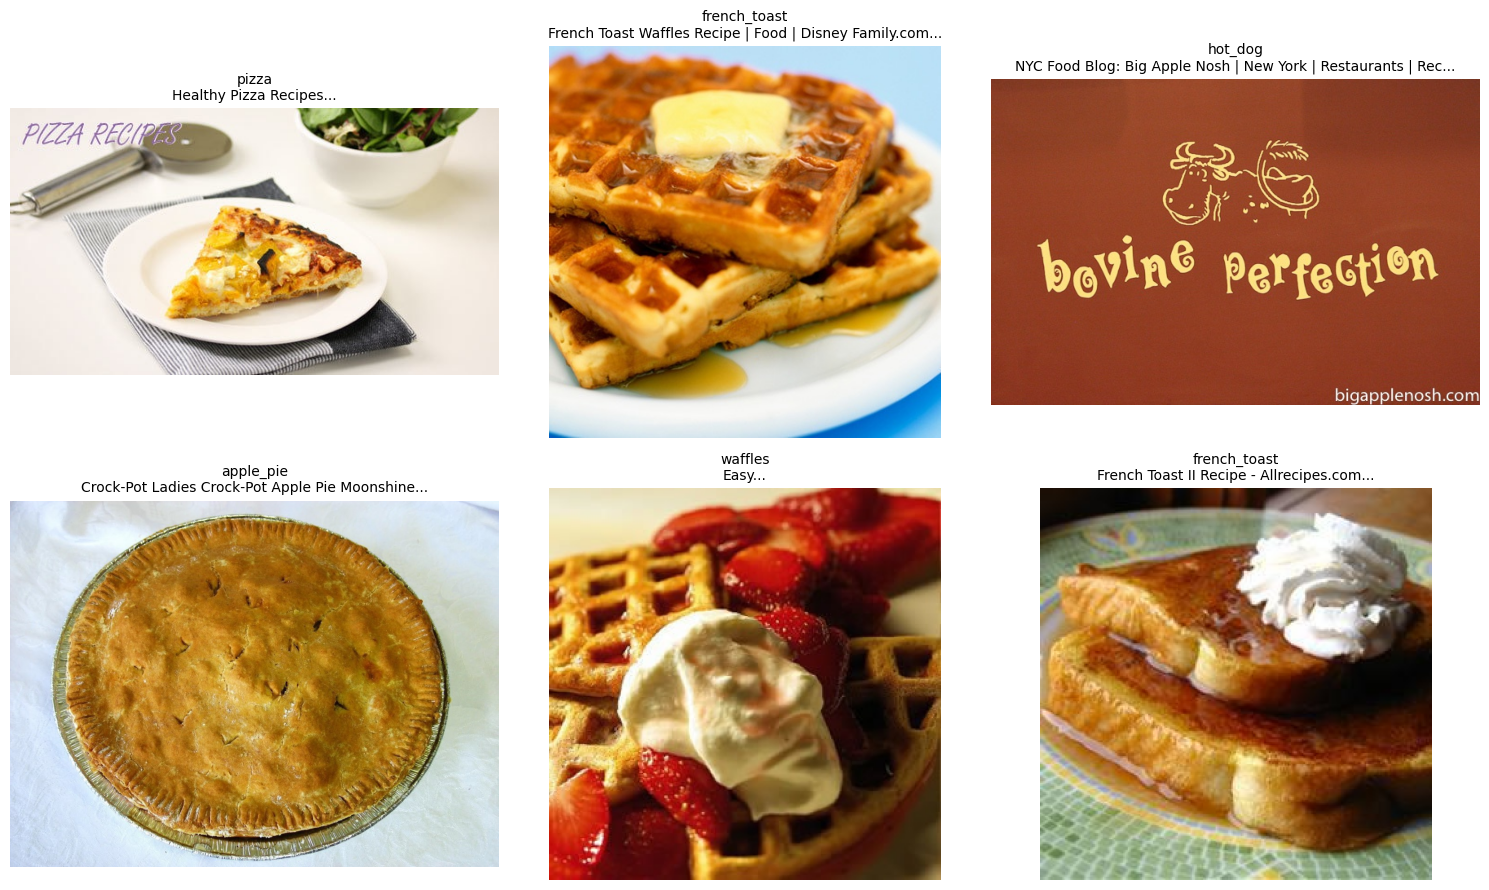

In [ ]:
sample_rows = train_pool_df.sample(min(6, len(train_pool_df)), random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, row in zip(axes, sample_rows.to_dict("records")):
    img = Image.open(row["resolved_image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f'{row["food"]}\n{row["text"][:60]}...', fontsize=10)
    ax.axis("off")

for ax in axes[len(sample_rows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Load pretrained CLIP

In [ ]:
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
print("Loaded CLIP ViT-B/32")

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 129MiB/s]


Loaded CLIP ViT-B/32


## Dataset + DataLoader helpers

In [ ]:
class MultimodalFoodDataset(Dataset):
    def __init__(self, dataframe, preprocess):
        self.df = dataframe.reset_index(drop=True)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["resolved_image_path"]).convert("RGB")
        image = self.preprocess(image)
        text = row["text"]
        label = int(row["label_id"])
        return image, text, label


def collate_clip(batch):
    images, texts, labels = zip(*batch)
    images = torch.stack(images, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return images, list(texts), labels


def make_loader(df, batch_size=BATCH_SIZE, shuffle=False):
    ds = MultimodalFoodDataset(df, clip_preprocess)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_clip,
    )

## Encode the dataset with CLIP

For each sample we compute:
- `image_features`
- `text_features`
- `fused_features = normalize(IMAGE_WEIGHT * image + TEXT_WEIGHT * text)`

We precompute them once so that zero-shot and all few-shot experiments reuse the same features.

In [ ]:
@torch.no_grad()
def encode_loader(loader, model, image_weight=IMAGE_WEIGHT, text_weight=TEXT_WEIGHT, desc="Encoding"):
    all_image_features = []
    all_text_features = []
    all_fused_features = []
    all_labels = []

    for images, texts, labels in tqdm(loader, desc=desc):
        images = images.to(device, non_blocking=True)
        tokens = clip.tokenize(texts, truncate=True).to(device)

        image_features = model.encode_image(images).float()
        text_features = model.encode_text(tokens).float()

        image_features = F.normalize(image_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)
        fused_features = F.normalize(
            image_weight * image_features + text_weight * text_features,
            dim=-1
        )

        all_image_features.append(image_features.cpu())
        all_text_features.append(text_features.cpu())
        all_fused_features.append(fused_features.cpu())
        all_labels.append(labels.cpu())

    return {
        "image": torch.cat(all_image_features, dim=0),
        "text": torch.cat(all_text_features, dim=0),
        "fused": torch.cat(all_fused_features, dim=0),
        "labels": torch.cat(all_labels, dim=0),
    }


train_pool_loader = make_loader(train_pool_df, shuffle=False)
val_loader = make_loader(val_df, shuffle=False)
test_loader = make_loader(test_df, shuffle=False)

train_feats = encode_loader(train_pool_loader, clip_model, desc="Encoding train pool")
val_feats = encode_loader(val_loader, clip_model, desc="Encoding validation")
test_feats = encode_loader(test_loader, clip_model, desc="Encoding test")

for split_name, feats in [("train_pool", train_feats), ("val", val_feats), ("test", test_feats)]:
    print(split_name, {k: tuple(v.shape) for k, v in feats.items()})

Encoding train pool:   0%|          | 0/94 [00:00<?, ?it/s]

Encoding validation:   0%|          | 0/17 [00:00<?, ?it/s]

Encoding test:   0%|          | 0/37 [00:00<?, ?it/s]

train_pool {'image': (5996, 512), 'text': (5996, 512), 'fused': (5996, 512), 'labels': (5996,)}
val {'image': (1059, 512), 'text': (1059, 512), 'fused': (1059, 512), 'labels': (1059,)}
test {'image': (2357, 512), 'text': (2357, 512), 'fused': (2357, 512), 'labels': (2357,)}


## Build zero-shot class prototypes from CLIP prompts

In [ ]:
@torch.no_grad()
def build_class_prototypes(class_names, templates, model):
    weights = []
    for class_name in class_names:
        clean_name = class_name.replace("_", " ")
        prompts = [template.format(clean_name) for template in templates]
        tokens = clip.tokenize(prompts).to(device)
        text_features = model.encode_text(tokens).float()
        text_features = F.normalize(text_features, dim=-1)
        class_feature = text_features.mean(dim=0, keepdim=True)
        class_feature = F.normalize(class_feature, dim=-1)
        weights.append(class_feature.squeeze(0).cpu())
    weights = torch.stack(weights, dim=1)  # [D, C]
    return weights

class_prototypes = build_class_prototypes(selected_classes, PROMPT_TEMPLATES, clip_model)
print("Class prototype matrix:", class_prototypes.shape)

Class prototype matrix: torch.Size([512, 10])


## Metric helpers

In [ ]:
def logits_from_features(features, class_weights, scale=100.0):
    return scale * (features @ class_weights)


def evaluate_logits(logits, labels, class_names):
    preds = logits.argmax(dim=1).cpu().numpy()
    y_true = labels.cpu().numpy()

    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "preds": preds,
        "y_true": y_true,
        "report": classification_report(y_true, preds, target_names=class_names, digits=4),
    }


def show_confusion(y_true, preds, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

## Zero-shot multimodal CLIP

This uses **no labeled support examples**.  
Prediction is based only on:
- the pretrained CLIP encoder
- the actual paired sample `(image, title)`
- the text prompts for class names

In [ ]:
val_zero_logits = logits_from_features(val_feats["fused"], class_prototypes)
test_zero_logits = logits_from_features(test_feats["fused"], class_prototypes)

val_zero_metrics = evaluate_logits(val_zero_logits, val_feats["labels"], selected_classes)
test_zero_metrics = evaluate_logits(test_zero_logits, test_feats["labels"], selected_classes)

zero_shot_result = {
    "approach": "Zero-shot CLIP (multimodal fused)",
    "shots": 0,
    "beta": None,
    "alpha": None,
    "test_accuracy": test_zero_metrics["accuracy"],
    "test_macro_f1": test_zero_metrics["macro_f1"],
    "preds": test_zero_metrics["preds"],
    "y_true": test_zero_metrics["y_true"],
    "report": test_zero_metrics["report"],
    "logits": test_zero_logits.cpu(),
    "probs": torch.softmax(test_zero_logits, dim=1).cpu(),
}

print("Validation zero-shot accuracy :", round(val_zero_metrics["accuracy"], 4))
print("Validation zero-shot macro-F1 :", round(val_zero_metrics["macro_f1"], 4))
print("Test zero-shot accuracy       :", round(test_zero_metrics["accuracy"], 4))
print("Test zero-shot macro-F1       :", round(test_zero_metrics["macro_f1"], 4))

Validation zero-shot accuracy : 0.9084
Validation zero-shot macro-F1 : 0.8877
Test zero-shot accuracy       : 0.9096
Test zero-shot macro-F1       : 0.8907


                     precision    recall  f1-score   support

macaroni_and_cheese     0.9665    0.9706    0.9686       238
       french_toast     0.9628    0.9790    0.9708       238
              sushi     0.8423    0.9916    0.9109       237
            risotto     0.9703    0.9703    0.9703       236
            ravioli     0.9705    0.9746    0.9725       236
            waffles     0.8855    0.9872    0.9336       235
              pizza     0.8147    0.9915    0.8944       235
            hot_dog     1.0000    0.2564    0.4082       234
          apple_pie     0.8208    0.9786    0.8928       234
             hummus     0.9789    0.9915    0.9851       234

           accuracy                         0.9096      2357
          macro avg     0.9212    0.9091    0.8907      2357
       weighted avg     0.9213    0.9096    0.8912      2357



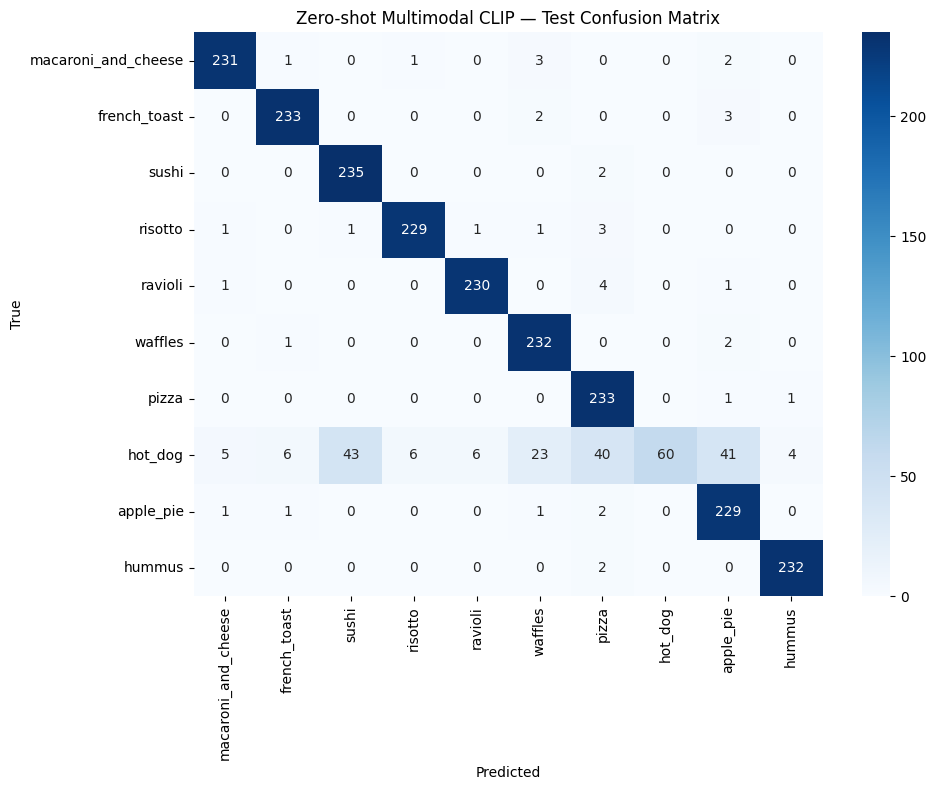

In [ ]:
print(test_zero_metrics["report"])
show_confusion(
    test_zero_metrics["y_true"],
    test_zero_metrics["preds"],
    selected_classes,
    title="Zero-shot Multimodal CLIP — Test Confusion Matrix",
)

## Few-shot support sampling

For each shot count `K`, we sample **K labeled examples per class** from the train pool.

Those support examples are used to build the **Tip-Adapter cache**:
- cache keys = fused CLIP features from support examples
- cache values = one-hot class labels

In [ ]:
def sample_support_indices(labels, shots, seed=SEED):
    rng = np.random.default_rng(seed)
    labels_np = np.asarray(labels)
    support_indices = []

    for class_id in sorted(np.unique(labels_np)):
        cls_idx = np.where(labels_np == class_id)[0]
        if len(cls_idx) < shots:
            raise ValueError(f"Class {class_id} has only {len(cls_idx)} samples, fewer than {shots} shots.")
        chosen = rng.choice(cls_idx, size=shots, replace=False)
        support_indices.extend(chosen.tolist())

    support_indices = np.array(sorted(support_indices))
    return support_indices


def build_cache(support_features, support_labels, num_classes):
    cache_keys = support_features.T.contiguous()  # [D, N]
    cache_values = F.one_hot(support_labels, num_classes=num_classes).float()  # [N, C]
    return cache_keys, cache_values


def tip_adapter_logits(query_features, class_weights, cache_keys, cache_values, beta, alpha):
    clip_logits = logits_from_features(query_features, class_weights)  # [B, C]
    affinity = query_features @ cache_keys                            # [B, N]
    cache_logits = torch.exp(-beta + beta * affinity) @ cache_values  # [B, C]
    return clip_logits + alpha * cache_logits


def search_tip_hparams(val_features, val_labels, class_weights, cache_keys, cache_values,
                       beta_grid=BETA_GRID, alpha_grid=ALPHA_GRID):
    best = {
        "beta": None,
        "alpha": None,
        "accuracy": -1.0,
        "macro_f1": -1.0,
    }

    for beta in beta_grid:
        for alpha in alpha_grid:
            logits = tip_adapter_logits(val_features, class_weights, cache_keys, cache_values, beta, alpha)
            metrics = evaluate_logits(logits, val_labels, selected_classes)
            if metrics["accuracy"] > best["accuracy"]:
                best = {
                    "beta": beta,
                    "alpha": alpha,
                    "accuracy": metrics["accuracy"],
                    "macro_f1": metrics["macro_f1"],
                }
    return best

## Run Tip-Adapter for multiple shot counts

In [ ]:
results = []

train_pool_fused = train_feats["fused"]
train_pool_labels = train_feats["labels"]
val_fused = val_feats["fused"]
val_labels = val_feats["labels"]
test_fused = test_feats["fused"]
test_labels = test_feats["labels"]

best_overall = None

for shots in SHOT_LIST:
    print("=" * 80)
    print(f"Running multimodal Tip-Adapter with {shots}-shot support per class")

    support_idx = sample_support_indices(train_pool_labels.numpy(), shots=shots, seed=SEED + shots)
    support_features = train_pool_fused[support_idx]
    support_labels = train_pool_labels[support_idx]

    cache_keys, cache_values = build_cache(
        support_features=support_features,
        support_labels=support_labels,
        num_classes=len(selected_classes),
    )

    best_hp = search_tip_hparams(
        val_features=val_fused,
        val_labels=val_labels,
        class_weights=class_prototypes,
        cache_keys=cache_keys,
        cache_values=cache_values,
    )

    print("Best validation setting:", best_hp)

    test_logits = tip_adapter_logits(
        query_features=test_fused,
        class_weights=class_prototypes,
        cache_keys=cache_keys,
        cache_values=cache_values,
        beta=best_hp["beta"],
        alpha=best_hp["alpha"],
    )

    test_metrics = evaluate_logits(test_logits, test_labels, selected_classes)

    result = {
        "approach": f"Tip-Adapter ({shots}-shot)",
        "shots": shots,
        "beta": best_hp["beta"],
        "alpha": best_hp["alpha"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "preds": test_metrics["preds"],
        "y_true": test_metrics["y_true"],
        "report": test_metrics["report"],
        "logits": test_logits.cpu(),
        "probs": torch.softmax(test_logits, dim=1).cpu(),
        "cache_keys": cache_keys.cpu(),
        "cache_values": cache_values.cpu(),
        "support_idx": support_idx,
    }
    results.append(result)

    if best_overall is None or result["test_accuracy"] > best_overall["test_accuracy"]:
        best_overall = result

    print(f"Test accuracy : {test_metrics['accuracy']:.4f}")
    print(f"Test macro-F1 : {test_metrics['macro_f1']:.4f}")

Running multimodal Tip-Adapter with 1-shot support per class
Best validation setting: {'beta': 5.0, 'alpha': 20.0, 'accuracy': 0.9140698772426817, 'macro_f1': 0.897036728562689}
Test accuracy : 0.9160
Test macro-F1 : 0.9029
Running multimodal Tip-Adapter with 4-shot support per class
Best validation setting: {'beta': 20.0, 'alpha': 20.0, 'accuracy': 0.9112370160528801, 'macro_f1': 0.890413350021378}
Test accuracy : 0.9101
Test macro-F1 : 0.8912
Running multimodal Tip-Adapter with 8-shot support per class
Best validation setting: {'beta': 5.0, 'alpha': 20.0, 'accuracy': 0.9490084985835694, 'macro_f1': 0.9448891436200549}
Test accuracy : 0.9419
Test macro-F1 : 0.9376
Running multimodal Tip-Adapter with 16-shot support per class
Best validation setting: {'beta': 5.0, 'alpha': 20.0, 'accuracy': 0.9329556185080264, 'macro_f1': 0.9250487797538435}
Test accuracy : 0.9359
Test macro-F1 : 0.9291


## Experimental results and comparison

In [ ]:
summary_rows = [
    {
        "approach": zero_shot_result["approach"],
        "shots": zero_shot_result["shots"],
        "beta": zero_shot_result["beta"],
        "alpha": zero_shot_result["alpha"],
        "test_accuracy": zero_shot_result["test_accuracy"],
        "test_macro_f1": zero_shot_result["test_macro_f1"],
    }
]

for r in results:
    summary_rows.append({
        "approach": r["approach"],
        "shots": r["shots"],
        "beta": r["beta"],
        "alpha": r["alpha"],
        "test_accuracy": r["test_accuracy"],
        "test_macro_f1": r["test_macro_f1"],
    })

results_df = pd.DataFrame(summary_rows).sort_values("shots").reset_index(drop=True)
display(results_df)

,approach,shots,beta,alpha,test_accuracy,test_macro_f1
0,Zero-shot CLIP (multimodal fused),0,NaN,NaN,0.909631,0.890722
1,Tip-Adapter (1-shot),1,5.0,20.0,0.915995,0.902879
2,Tip-Adapter (4-shot),4,20.0,20.0,0.910055,0.891162
3,Tip-Adapter (8-shot),8,5.0,20.0,0.941875,0.937616
4,Tip-Adapter (16-shot),16,5.0,20.0,0.935936,0.929111


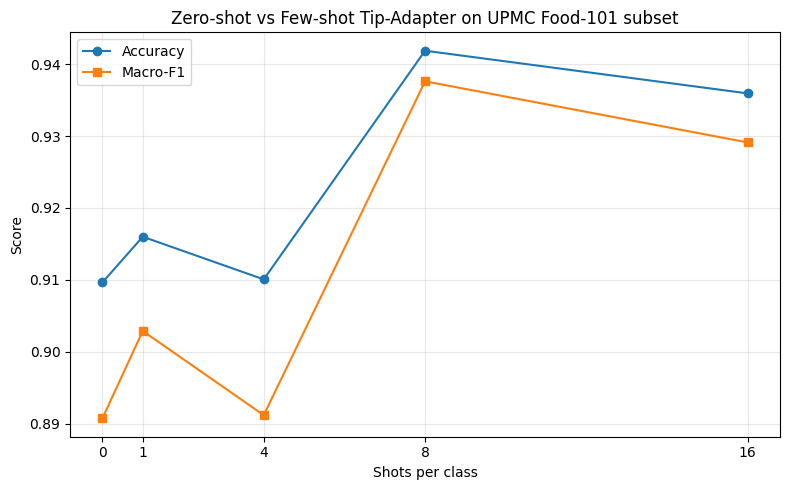

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["shots"], results_df["test_accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["shots"], results_df["test_macro_f1"], marker="s", label="Macro-F1")
plt.xticks(results_df["shots"])
plt.xlabel("Shots per class")
plt.ylabel("Score")
plt.title("Zero-shot vs Few-shot Tip-Adapter on UPMC Food-101 subset")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Best few-shot confusion matrix

Best few-shot approach: Tip-Adapter (8-shot)
                     precision    recall  f1-score   support

macaroni_and_cheese     0.9249    0.9832    0.9532       238
       french_toast     0.9555    0.9916    0.9732       238
              sushi     0.9828    0.9662    0.9745       237
            risotto     0.9617    0.9576    0.9597       236
            ravioli     0.9173    0.9873    0.9510       236
            waffles     0.9271    0.9745    0.9502       235
              pizza     0.9398    0.9957    0.9669       235
            hot_dog     0.9790    0.5983    0.7427       234
          apple_pie     0.9048    0.9744    0.9383       234
             hummus     0.9467    0.9872    0.9665       234

           accuracy                         0.9419      2357
          macro avg     0.9440    0.9416    0.9376      2357
       weighted avg     0.9440    0.9419    0.9378      2357



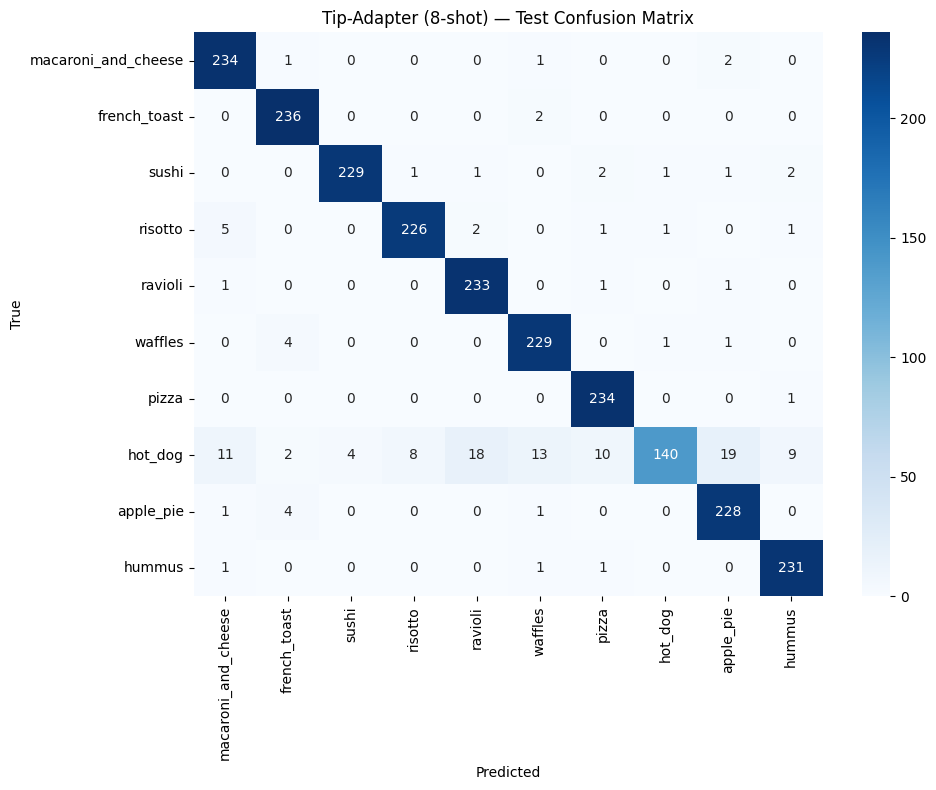

In [ ]:
print("Best few-shot approach:", best_overall["approach"])
print(best_overall["report"])

show_confusion(
    best_overall["y_true"],
    best_overall["preds"],
    selected_classes,
    title=f'{best_overall["approach"]} — Test Confusion Matrix',
)

## Extension

The assignment allows extension work such as **error analysis**, **calibration**, **augmentation / robustness**, **model efficiency**, or other justified directions. For this CLIP + multimodal Tip-Adapter notebook, the most suitable extensions are:

1. **Error analysis**: inspect which food classes are confused and show hard misclassified examples.
2. **Calibration**: compare whether zero-shot or few-shot confidence is better aligned with accuracy.
3. **Modality ablation (other justified direction)**: compare **image-only**, **text-only**, and **multimodal fused** features to show whether paired title text really helps the classifier.

These extensions fit the current pipeline because they reuse the same pretrained CLIP encoder and the same fixed train / validation / test split, so the comparisons stay fair.

,approach,accuracy,macro_f1,avg_confidence,ece,confidently_correct_rate@0.9
0,Zero-shot CLIP (multimodal fused),0.909631,0.890722,0.945124,0.035493,0.871447
1,Tip-Adapter (8-shot),0.941875,0.937616,0.980677,0.038802,0.919389


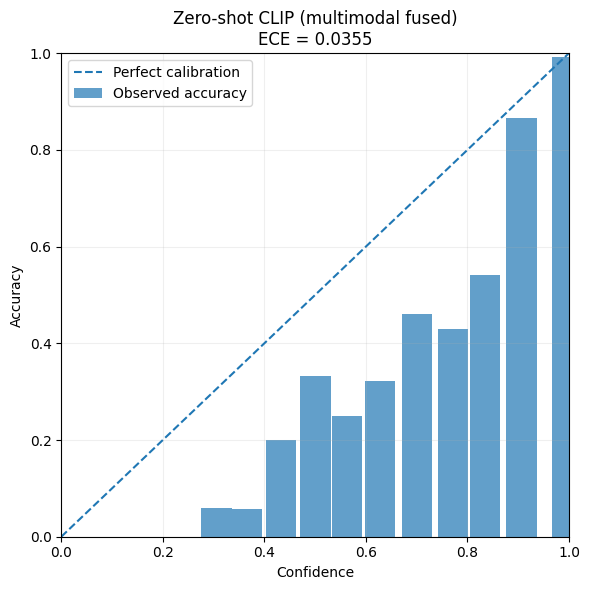

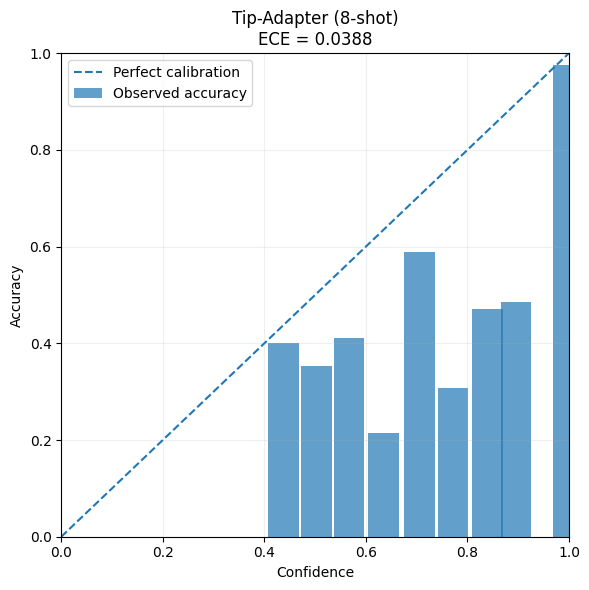

(0.038802248912187365,
     bin  count  avg_confidence  accuracy
 0     0      0             NaN       NaN
 1     1      0             NaN       NaN
 2     2      0             NaN       NaN
 3     3      0             NaN       NaN
 4     4      1        0.306473  0.000000
 5     5      2        0.359885  0.000000
 6     6     10        0.437327  0.400000
 7     7     17        0.502788  0.352941
 8     8     17        0.566442  0.411765
 9     9     14        0.634196  0.214286
 10   10     17        0.705659  0.588235
 11   11     13        0.771683  0.307692
 12   12     17        0.839453  0.470588
 13   13     33        0.895512  0.484848
 14   14   2216        0.998714  0.975632)

In [ ]:
# ============================================================
# Extension 1: Calibration (ECE + reliability diagram)
# ============================================================

def expected_calibration_error(probs, y_true, n_bins=15):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)

    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    correctness = (predictions == y_true).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if mask.sum() == 0:
            rows.append({
                "bin": i,
                "count": 0,
                "avg_confidence": np.nan,
                "accuracy": np.nan,
            })
            continue

        avg_conf = confidences[mask].mean()
        avg_acc = correctness[mask].mean()
        ece += (mask.mean()) * abs(avg_acc - avg_conf)

        rows.append({
            "bin": i,
            "count": int(mask.sum()),
            "avg_confidence": float(avg_conf),
            "accuracy": float(avg_acc),
        })

    return float(ece), pd.DataFrame(rows)


def plot_reliability_diagram(probs, y_true, title, n_bins=15):
    ece, calib_df = expected_calibration_error(probs, y_true, n_bins=n_bins)
    plot_df = calib_df.dropna().copy()

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.bar(
        plot_df["avg_confidence"],
        plot_df["accuracy"],
        width=1.0 / n_bins * 0.9,
        align="center",
        alpha=0.7,
        label="Observed accuracy",
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"{title}\nECE = {ece:.4f}")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return ece, calib_df


calibration_rows = []

for result in [zero_shot_result, best_overall]:
    probs = result["probs"].numpy()
    y_true = result["y_true"]
    preds = result["preds"]
    confidences = probs.max(axis=1)

    ece, _ = expected_calibration_error(probs, y_true, n_bins=15)

    calibration_rows.append({
        "approach": result["approach"],
        "accuracy": accuracy_score(y_true, preds),
        "macro_f1": f1_score(y_true, preds, average="macro"),
        "avg_confidence": confidences.mean(),
        "ece": ece,
        "confidently_correct_rate@0.9": float(((preds == y_true) & (confidences >= 0.9)).mean()),
    })

calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df)

plot_reliability_diagram(
    zero_shot_result["probs"].numpy(),
    zero_shot_result["y_true"],
    title="Zero-shot CLIP (multimodal fused)",
)

plot_reliability_diagram(
    best_overall["probs"].numpy(),
    best_overall["y_true"],
    title=best_overall["approach"],
)

Top confusion pairs for the best few-shot model:


,true_class,predicted_class,count
0,hot_dog,apple_pie,19
1,hot_dog,ravioli,18
2,hot_dog,waffles,13
3,hot_dog,macaroni_and_cheese,11
4,hot_dog,pizza,10
5,hot_dog,hummus,9
6,hot_dog,risotto,8
7,risotto,macaroni_and_cheese,5
8,hot_dog,sushi,4
9,apple_pie,french_toast,4


Highest-confidence mistakes:


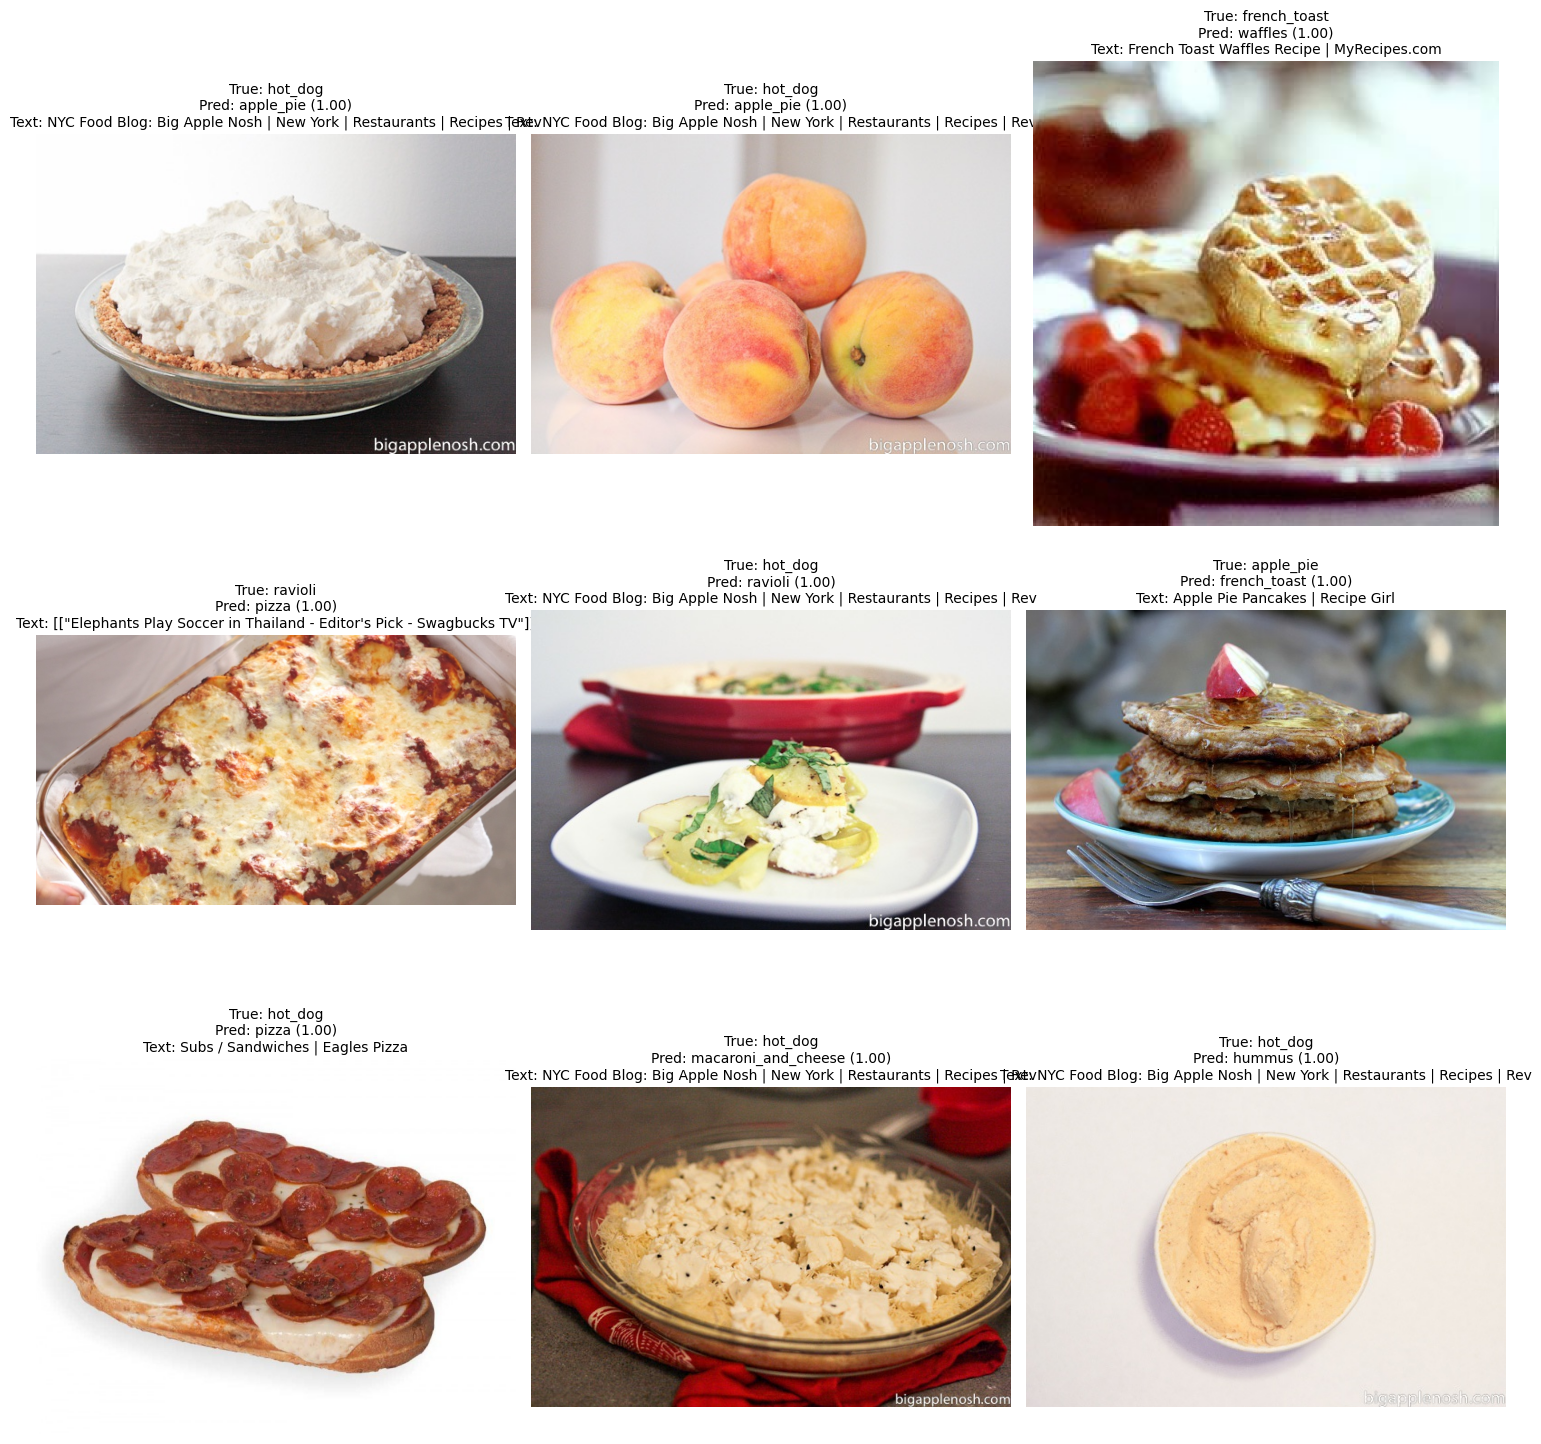

In [ ]:
# ============================================================
# Extension 2: Error analysis
# ============================================================

def build_confusion_pairs_df(y_true, preds, class_names):
    cm = confusion_matrix(y_true, preds)
    rows = []
    for true_idx in range(len(class_names)):
        for pred_idx in range(len(class_names)):
            if true_idx == pred_idx or cm[true_idx, pred_idx] == 0:
                continue
            rows.append({
                "true_class": class_names[true_idx],
                "predicted_class": class_names[pred_idx],
                "count": int(cm[true_idx, pred_idx]),
            })
    if not rows:
        return pd.DataFrame(columns=["true_class", "predicted_class", "count"])
    return pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)


def show_misclassified_examples(df, y_true, preds, probs, class_names, n=9, sort_by="confidence"):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    preds = np.asarray(preds)

    wrong_idx = np.where(y_true != preds)[0]
    if len(wrong_idx) == 0:
        print("No misclassified examples to display.")
        return

    confidences = probs.max(axis=1)

    if sort_by == "confidence":
        ranked = wrong_idx[np.argsort(-confidences[wrong_idx])]
    else:
        margins = np.partition(probs, -2, axis=1)[:, -1] - np.partition(probs, -2, axis=1)[:, -2]
        ranked = wrong_idx[np.argsort(margins[wrong_idx])]

    chosen = ranked[:n]
    ncols = min(3, len(chosen))
    nrows = int(np.ceil(len(chosen) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(chosen):]:
        ax.axis("off")

    for ax, idx in zip(axes, chosen):
        row = df.iloc[idx]
        image = Image.open(row["resolved_image_path"]).convert("RGB")
        ax.imshow(image)
        ax.axis("off")

        pred_probs = probs[idx]
        pred_id = preds[idx]
        true_id = y_true[idx]
        conf = pred_probs[pred_id]

        title_text = (
            f"True: {class_names[true_id]}\n"
            f"Pred: {class_names[pred_id]} ({conf:.2f})\n"
            f"Text: {row['text'][:70]}"
        )
        ax.set_title(title_text, fontsize=10)

    plt.tight_layout()
    plt.show()


best_confusions_df = build_confusion_pairs_df(
    best_overall["y_true"],
    best_overall["preds"],
    selected_classes,
)

print("Top confusion pairs for the best few-shot model:")
display(best_confusions_df.head(10))

print("Highest-confidence mistakes:")
show_misclassified_examples(
    test_df.reset_index(drop=True),
    best_overall["y_true"],
    best_overall["preds"],
    best_overall["probs"].numpy(),
    selected_classes,
    n=9,
    sort_by="confidence",
)

,setting,feature_bank,shots,accuracy,macro_f1
0,Zero-shot (image),image,0,0.806109,0.792563
1,Tip-Adapter 1-shot (image),image,1,0.806109,0.792696
2,Tip-Adapter 4-shot (image),image,4,0.809079,0.794410
3,Tip-Adapter 8-shot (image),image,8,0.802715,0.785224
4,Tip-Adapter 16-shot (image),image,16,0.801018,0.783560
5,Zero-shot (text),text,0,0.850658,0.833644
6,Tip-Adapter 1-shot (text),text,1,0.910479,0.914478
7,Tip-Adapter 4-shot (text),text,4,0.915146,0.918205
8,Tip-Adapter 8-shot (text),text,8,0.919389,0.923174
9,Tip-Adapter 16-shot (text),text,16,0.921935,0.925637


Best result obtained for each feature bank:


,feature_bank,setting,shots,accuracy,macro_f1
0,fused,Tip-Adapter 1-shot (fused),1,0.924480,0.914788
1,image,Tip-Adapter 4-shot (image),4,0.809079,0.794410
2,text,Tip-Adapter 16-shot (text),16,0.921935,0.925637


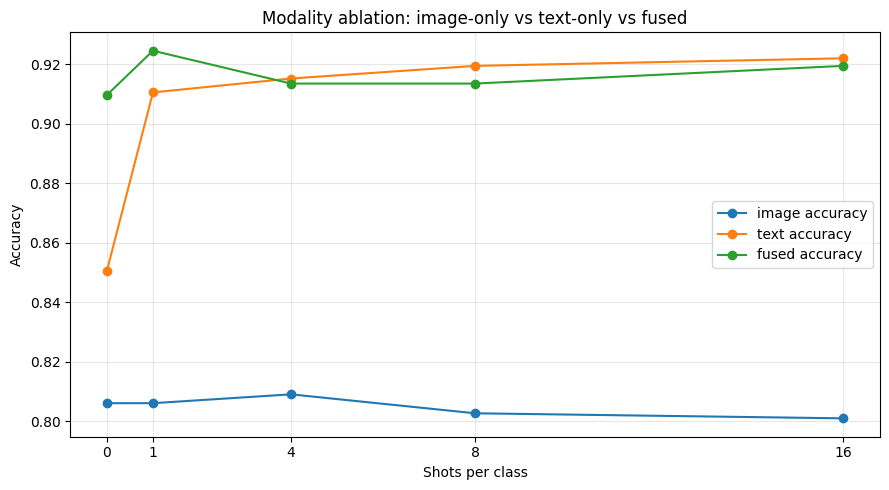

In [ ]:
# ============================================================
# Extension 3: Modality ablation (image-only vs text-only vs fused)
# ============================================================

def run_zero_shot_for_feature_bank(feature_key):
    logits = logits_from_features(test_feats[feature_key], class_prototypes)
    metrics = evaluate_logits(logits, test_feats["labels"], selected_classes)
    return {
        "setting": f"Zero-shot ({feature_key})",
        "feature_bank": feature_key,
        "shots": 0,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "logits": logits.cpu(),
        "preds": metrics["preds"],
        "y_true": metrics["y_true"],
    }


def run_tip_adapter_for_feature_bank(feature_key, shots_list=SHOT_LIST):
    feature_results = []
    train_bank = train_feats[feature_key]
    val_bank = val_feats[feature_key]
    test_bank = test_feats[feature_key]
    labels_train = train_feats["labels"]
    labels_val = val_feats["labels"]
    labels_test = test_feats["labels"]

    for shots in shots_list:
        support_idx = sample_support_indices(labels_train.numpy(), shots=shots, seed=SEED + 1000 + shots)
        support_features = train_bank[support_idx]
        support_labels = labels_train[support_idx]

        cache_keys, cache_values = build_cache(
            support_features=support_features,
            support_labels=support_labels,
            num_classes=len(selected_classes),
        )

        best_hp = search_tip_hparams(
            val_features=val_bank,
            val_labels=labels_val,
            class_weights=class_prototypes,
            cache_keys=cache_keys,
            cache_values=cache_values,
        )

        logits = tip_adapter_logits(
            query_features=test_bank,
            class_weights=class_prototypes,
            cache_keys=cache_keys,
            cache_values=cache_values,
            beta=best_hp["beta"],
            alpha=best_hp["alpha"],
        )

        metrics = evaluate_logits(logits, labels_test, selected_classes)
        feature_results.append({
            "setting": f"Tip-Adapter {shots}-shot ({feature_key})",
            "feature_bank": feature_key,
            "shots": shots,
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "beta": best_hp["beta"],
            "alpha": best_hp["alpha"],
        })

    return feature_results


ablation_rows = []
for key in ["image", "text", "fused"]:
    ablation_rows.append(run_zero_shot_for_feature_bank(key))
    ablation_rows.extend(run_tip_adapter_for_feature_bank(key, shots_list=SHOT_LIST))

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df[["setting", "feature_bank", "shots", "accuracy", "macro_f1"]])

best_per_feature_df = (
    ablation_df.sort_values(["feature_bank", "accuracy"], ascending=[True, False])
    .groupby("feature_bank", as_index=False)
    .first()[["feature_bank", "setting", "shots", "accuracy", "macro_f1"]]
)
print("Best result obtained for each feature bank:")
display(best_per_feature_df)

plt.figure(figsize=(9, 5))
for key in ["image", "text", "fused"]:
    plot_df = ablation_df[ablation_df["feature_bank"] == key].sort_values("shots")
    plt.plot(plot_df["shots"], plot_df["accuracy"], marker="o", label=f"{key} accuracy")
plt.xticks(sorted(ablation_df["shots"].unique()))
plt.xlabel("Shots per class")
plt.ylabel("Accuracy")
plt.title("Modality ablation: image-only vs text-only vs fused")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Error analysis
- Show the confusion matrix of the best few-shot model.
- Report the most common confusion pairs and include several representative failure cases.
- Briefly explain whether the errors are visually similar foods, ambiguous titles, or both.

### Calibration
- Report **ECE** and reliability diagrams for zero-shot and the best few-shot model.
- State whether the few-shot model becomes more accurate, and whether it also becomes better calibrated or more overconfident.

### Modality ablation
- Compare **image-only**, **text-only**, and **multimodal fused** variants under the same CLIP backbone and the same support-shot protocol.
- Use this section to justify the value of genuine image–text pairing in the UPMC Food-101 dataset.

## Future next improvements

To extend this notebook even further later we can:
- add robustness tests with image blur / noise or text word-dropout
- compare fusion weights
- add a small Gradio demo
- compare frozen Tip-Adapter against a learned linear probe
- export all tables to CSV for direct insertion into the final report

## References used in the implementation

- OpenAI CLIP
- Tip-Adapter
- UPMC Food-101 / Kaggle packaged version with title CSV files